# SIGReg — Sketched Isotropic Gaussian Regularization

Anti-collapse regularizer from [LeJEPA](https://arxiv.org/abs/2511.08544) (Balestriero & LeCun, 2025).

**Idea:** the optimal embedding law for downstream risk is isotropic Gaussian `N(0, I)`.
SIGReg pushes a batch toward that law by:

1. sampling random unit directions (Cramér–Wold / sketching)
2. projecting embeddings onto each direction
3. scoring each 1-D slice with the **Epps–Pulley** characteristic-function test against `N(0, 1)`
4. averaging over slices

Minimized when mean is zero, covariance is identity, and every projection is Gaussian.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt

from pytorch_katas import SIGReg, sigreg_loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## Module API

`SIGReg` is a drop-in `nn.Module`. Pass embeddings of shape `(N, D)` or `(V, N, D)`.


In [3]:
criterion = SIGReg(num_slices=512).to(device)
print(criterion)

z = torch.randn(256, 64, device=device, requires_grad=True)
loss = criterion(z)
loss.backward()
print(f"loss={loss.item():.4f}, grad_norm={z.grad.norm().item():.4f}")

SIGReg(num_slices=512, n_knots=17, t_max=3.0, reduction='mean')
loss=1.1149, grad_norm=0.1422


## Failure modes vs isotropic Gaussian

Collapsed, low-rank, shifted, and anisotropic batches should score much higher than `N(0, I)`.


isotropic N(0, I)          1.2252
full collapse           2205.3740


rank-1 subspace          338.9973
shifted mean=2          2101.5654
anisotropic scales      1014.3979


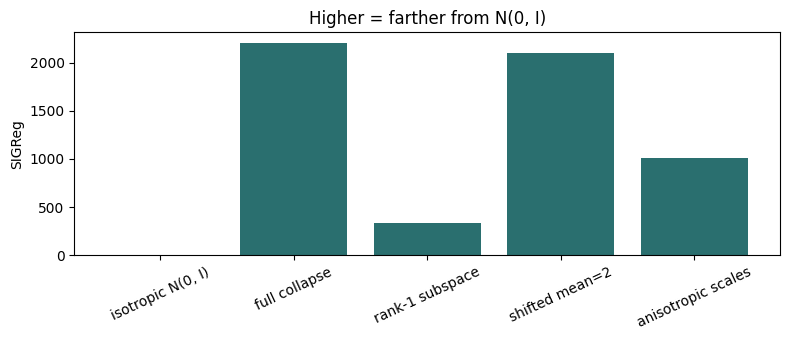

In [4]:
torch.manual_seed(0)
N, D = 2048, 32
crit = SIGReg(num_slices=512).to(device)

cases = {
    "isotropic N(0, I)": torch.randn(N, D, device=device),
    "full collapse": torch.ones(N, D, device=device),
    "rank-1 subspace": torch.randn(N, 1, device=device) @ torch.randn(1, D, device=device),
    "shifted mean=2": torch.randn(N, D, device=device) + 2,
    "anisotropic scales": torch.randn(N, D, device=device) * torch.linspace(0.2, 5.0, D, device=device),
}

scores = {}
for name, z in cases.items():
    g = torch.Generator(device=device).manual_seed(0)
    scores[name] = crit(z, generator=g).item()
    print(f"{name:22s} {scores[name]:10.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(scores.keys(), scores.values(), color="#2a6f6f")
ax.set_ylabel("SIGReg")
ax.set_title("Higher = farther from N(0, I)")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

## Whitening by minimizing SIGReg alone

No reconstruction, no teacher — only SIGReg. An anisotropic, shifted cloud should become roughly isotropic.


final loss=2.8815
mean norm=0.2820
std range=[0.841, 1.069]


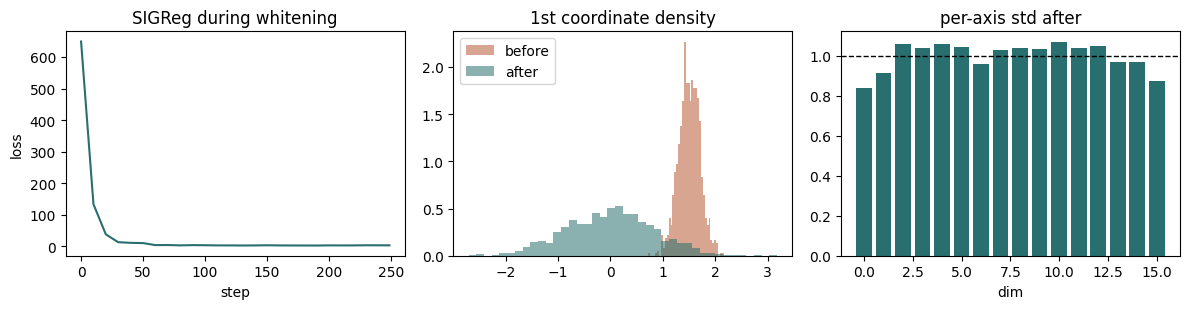

In [5]:
torch.manual_seed(1)
N, D = 1024, 16
X = torch.randn(N, D, device=device)
X = X * torch.linspace(0.2, 5.0, D, device=device) + 1.5

W = torch.nn.Parameter(torch.eye(D, device=device))
b = torch.nn.Parameter(torch.zeros(D, device=device))
opt = torch.optim.Adam([W, b], lr=5e-2)

curve = []
for step in range(250):
    Z = X @ W + b
    loss = sigreg_loss(Z, num_slices=256)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 10 == 0 or step == 249:
        curve.append((step, loss.item()))

steps, vals = zip(*curve)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

axes[0].plot(steps, vals, color="#2a6f6f")
axes[0].set_title("SIGReg during whitening")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")

with torch.no_grad():
    Z0 = X
    Z1 = X @ W + b
    axes[1].hist(Z0[:, 0].cpu(), bins=40, density=True, alpha=0.55, label="before", color="#b85c38")
    axes[1].hist(Z1[:, 0].cpu(), bins=40, density=True, alpha=0.55, label="after", color="#2a6f6f")
    axes[1].set_title("1st coordinate density")
    axes[1].legend()

    stds = Z1.std(0).cpu()
    axes[2].bar(range(D), stds, color="#2a6f6f")
    axes[2].axhline(1.0, color="black", lw=1, ls="--")
    axes[2].set_title("per-axis std after")
    axes[2].set_xlabel("dim")

print(f"final loss={vals[-1]:.4f}")
print(f"mean norm={Z1.mean(0).norm().item():.4f}")
print(f"std range=[{stds.min():.3f}, {stds.max():.3f}]")
fig.tight_layout()
plt.show()

## Usage in a LeJEPA-style objective

```python
lam = 0.05
pred_loss = (proj.mean(0) - proj).square().mean()  # invariance / prediction
reg_loss = SIGReg(num_slices=1024)(proj)
loss = lam * reg_loss + (1 - lam) * pred_loss
```

`SIGReg` returns only the distribution-matching term — λ and the prediction loss stay in the training loop.
